# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

## Part 1: Data Preparation and Exploration

In [3]:
# import libraries

In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [496]:
# Data loading and parsing the date column appropriately

In [498]:
data = pd.read_csv('exchange_rate.csv')

In [500]:
data

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [502]:
data=pd.read_csv('exchange_rate.csv', header=None)

In [504]:
data

,0,1
0,date,Ex_rate
1,01-01-1990 00:00,0.7855
2,02-01-1990 00:00,0.7818
3,03-01-1990 00:00,0.7867
4,04-01-1990 00:00,0.786
...,...,...
7584,06-10-2010 00:00,0.718494
7585,07-10-2010 00:00,0.721839
7586,08-10-2010 00:00,0.723197
7587,09-10-2010 00:00,0.720825


In [506]:
data=data.drop(index=0)
# Dropping first row

In [508]:
# Parsing the date column appropriately
data.columns=['Month','Exchange_rates']
data['Month']=pd.to_datetime(data['Month'],format='%d-%m-%Y %H:%M')
data = data.set_index('Month')
data.head(12)

,Exchange_rates
Month,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.786
1990-01-05,0.7849
1990-01-06,0.7866
1990-01-07,0.7886
1990-01-08,0.791
1990-01-09,0.7939


In [510]:
# Plot time series data

In [512]:
type(data)

pandas.core.frame.DataFrame

In [514]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Exchange_rates  7588 non-null   object
dtypes: object(1)
memory usage: 118.6+ KB


In [516]:
data['Exchange_rates']=pd.to_numeric(data['Exchange_rates'],errors='ignore')

# Conversion from obj to numeric data type

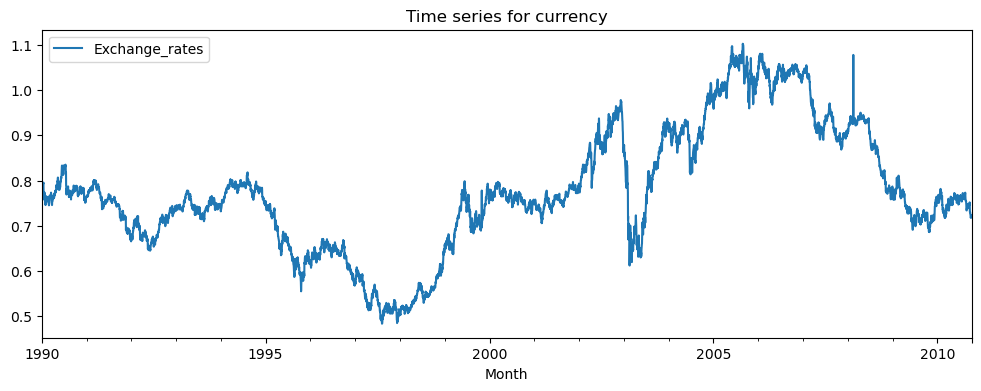

In [518]:
data.plot(figsize=(12,4))
plt.legend(loc='best')
plt.title('Time series for currency')
plt.show()

In [520]:
# There are no missing values. Hence missing value treatment is not required.

In [522]:
# Outlier detection

In [524]:
# Box plot and interquartile range

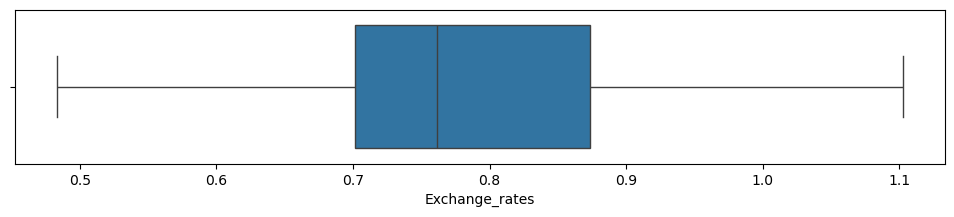

In [526]:
import seaborn as sns
fig = plt.subplots(figsize=(12,2))
ax=sns.boxplot(x=data['Exchange_rates'], whis=1.5)
plt.show()

In [528]:
# No outliers can be seen

In [530]:
# Histogram plot

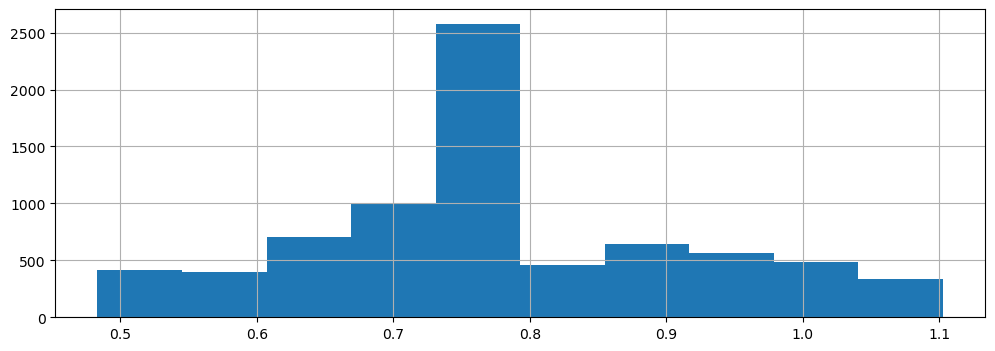

In [532]:
fig=data.Exchange_rates.hist(figsize=(12,4))

plt.show()

In [534]:
# Outliers not detected

In [536]:
# Time series decomposition

In [538]:
# Additive seasonal decomposition

In [540]:
# 1. Additive Seasonal Decomposition
# In an additive model, the time series is assumed to be the sum of its components:
# Yt=Trendt+Seasonalityt+ResidualtY_t = Trend_t + Seasonality_t + Residual_t 
# ✅ When to Use?
# •	When the seasonal variations are roughly constant over time (i.e., they do not increase as the values of the time series increase).
# •	The trend and seasonality do not depend on the magnitude of the data.
# Example:
# •	Monthly temperature changes (e.g., fluctuations of ±5°C throughout the year).
# •	Electricity consumption where seasonal variation remains nearly constant over time.
# ________________________________________


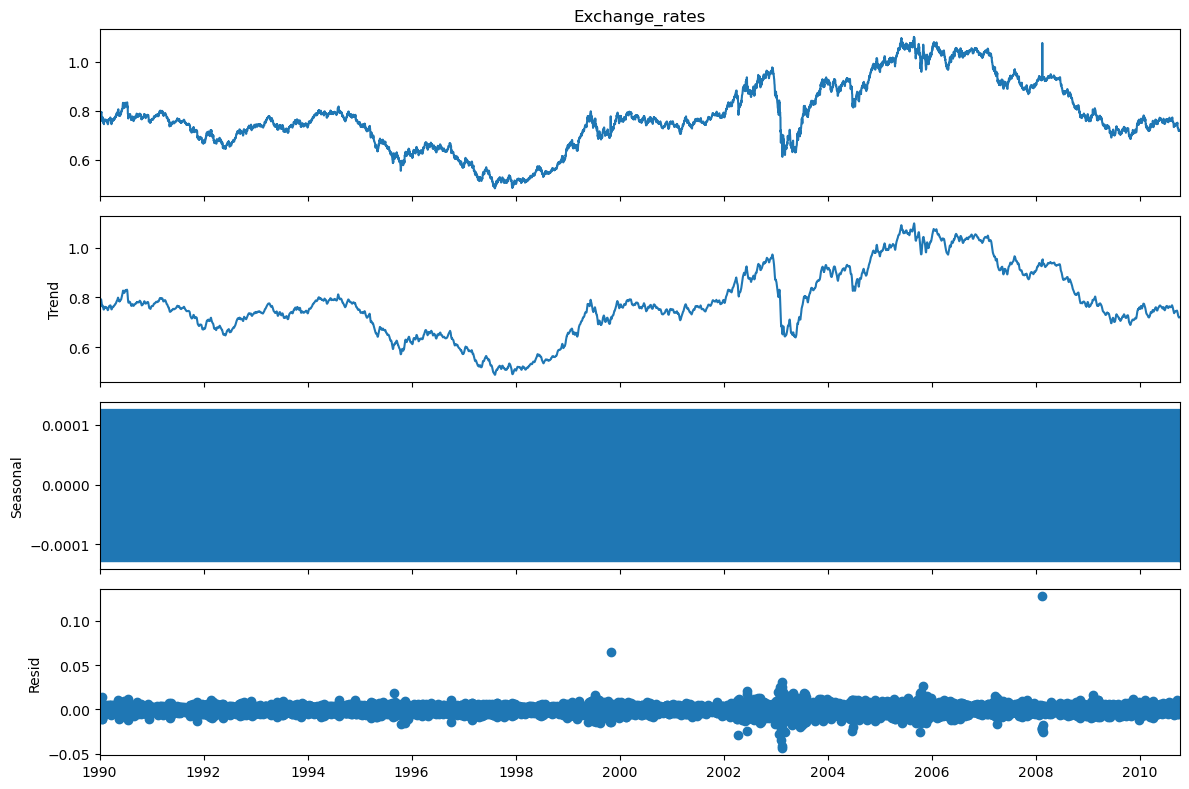

In [542]:
from pylab import rcParams
import statsmodels.api as sm
rcParams['figure.figsize']=12,8
decomposition = sm.tsa.seasonal_decompose(data.Exchange_rates, model='additive') #additive seasonal index
fig=decomposition.plot()
plt.show()

## Part 2: Model Building - ARIMA

## Build and evaluate time series forecast

## Split time series data into training and test set

In [547]:
train_len=6071
train=data[0:train_len] #first 120 months as training set
test=data[train_len:] #last 24 months as out-of-time test set
train.tail()


,Exchange_rates
Month,
2006-08-11,1.027591
2006-08-12,1.022349
2006-08-13,1.023395
2006-08-14,1.023552
2006-08-15,1.025347


In [549]:
# In an ARIMA (AutoRegressive Integrated Moving Average) model, the data is usually split into training and testing sets based on a time-based split (rather than random splitting like in machine learning).

# 📌 Common Train-Test Splits for Time Series
# Since ARIMA models are used for forecasting, you generally keep 80–90% for training and 10–20% for testing.

# For 7,589 rows, here are the typical splits:

# 80% Training, 20% Testing:
# Training: ~6,071 rows
# Testing: ~1,518 rows
# 90% Training, 10% Testing:
# Training: ~6,830 rows
# Testing: ~759 rows
# 📌 Key Considerations
# ✔ Never shuffle time series data while splitting. The test set should always come after the training set.
# ✔ If the dataset has strong seasonality, ensure the test set covers at least one full seasonal cycle (e.g., a full year for monthly data).
# ✔ Consider rolling forecast validation if you need a dynamic test strategy instead of a single test split.

In [551]:
data.shape

(7588, 1)

In [553]:
# Stationarity vs non- stationarity time series

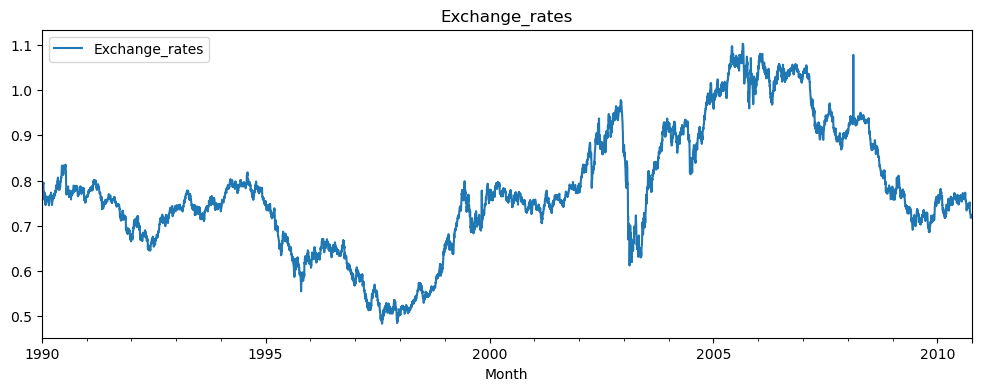

In [555]:
data['Exchange_rates'].plot(figsize=(12,4))
plt.legend(loc='best')
plt.title('Exchange_rates')
plt.show(block=False)

In [557]:
# Augmented Dickey-Fuller (ADF) test

In [559]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(data['Exchange_rates'])

print('ADF Statistic: %f'% adf_test[0])
print('Critical Values @ 0.05: %.2f'% adf_test[4]['5%'])
print('p-value: %f'% adf_test[1])

ADF Statistic: -1.664994
Critical Values @ 0.05: -2.86
p-value: 0.449233


In [562]:
# A p-value of 0.44 in the Augmented Dickey-Fuller (ADF) test indicates that the null hypothesis cannot be rejected. Here's what that means in more detail:

# Augmented Dickey-Fuller (ADF) Test:
# Purpose: The ADF test is used to check for the presence of a unit root in a time series sample, which indicates whether the series is non-stationary.

# Null Hypothesis (H0): The time series has a unit root (i.e., it is non-stationary).

# Alternative Hypothesis (H1): The time series does not have a unit root (i.e., it is stationary).

# Interpretation:
# P-value of 0.44: This p-value is quite high and much greater than common significance levels like 0.05 or 0.01. As a result, you do not have sufficient evidence to reject the null hypothesis.

# Conclusion: The time series is likely non-stationary. In other words, it has a unit root, meaning its statistical properties such as mean and variance change over time.

# Next Steps:
# If your goal is to work with stationary data, you may need to transform the series to make it stationary. Common techniques include:

# Differencing: Subtract the previous observation from the current observation.

# Log Transformation: Apply a logarithmic transformation to stabilize variance.

# De-trending: Remove any trends in the data.

# Redoing with KPSS test

## Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test

In [565]:
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(data['Exchange_rates'])

print ('KPSS Statistic: %f'% kpss_test[0])
print ('Critical values @ 0.05: %.2f'% kpss_test[3]['5%'])
print ('p-value: %f'% kpss_test[1])

KPSS Statistic: 5.291660
Critical values @ 0.05: 0.46
p-value: 0.010000


In [567]:
# The data is non stationary as p<0.05 in KPSS too.

## Box Cox transformation to make variance constant 

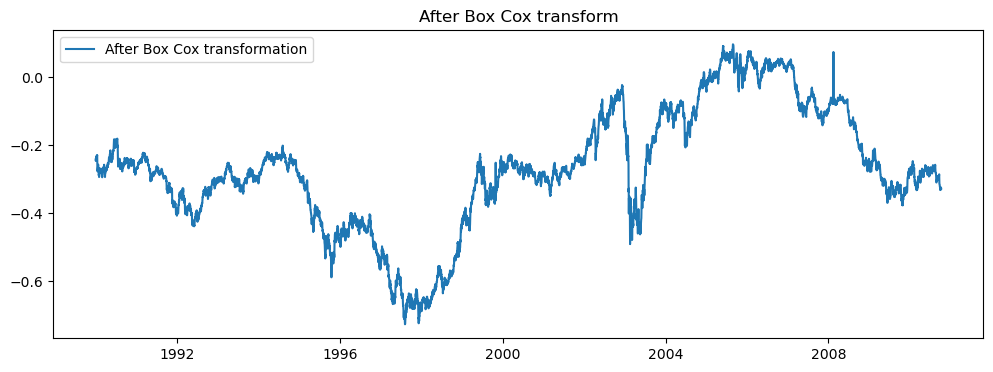

In [570]:
from scipy.stats import boxcox
data_boxcox = pd.Series(boxcox(data['Exchange_rates'],lmbda=0), index=data.index)

plt.figure(figsize=(12,4))
plt.plot(data_boxcox, label='After Box Cox transformation')
plt.legend(loc='best')
plt.title('After Box Cox transform')
plt.show()

## Differencing to remove trend

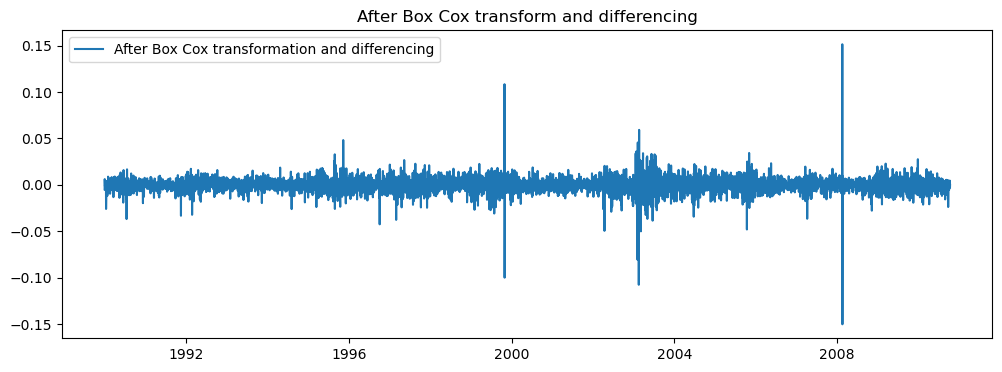

In [573]:
data_boxcox_diff = pd.Series(data_boxcox-data_boxcox.shift(), data.index)
plt.figure(figsize=(12,4))
plt.plot(data_boxcox_diff, label = 'After Box Cox transformation and differencing')
plt.legend(loc='best')
plt.title('After Box Cox transform and differencing')
plt.show()

In [576]:
data_boxcox_diff.dropna(inplace=True)

In [578]:
data_boxcox_diff.tail()

Month
2010-10-06   -0.000288
2010-10-07    0.004645
2010-10-08    0.001880
2010-10-09   -0.003285
2010-10-10    0.000000
dtype: float64

## Augmented Dickey-Fuller (ADF) test

In [581]:
adf_test = adfuller(data_boxcox_diff)

print('ADF Statistic: %f'% adf_test[0])
print('Critical Values @ 0.05: %.2f'% adf_test[4]['5%'])
print('p-value: %f'% adf_test[1])

ADF Statistic: -31.121200
Critical Values @ 0.05: -2.86
p-value: 0.000000


In [583]:
# Since p values<0.05, the series is now stationary and no 
# further differencing is needed.

## Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test

In [586]:
kpss_test = kpss(data_boxcox_diff)

print ('KPSS Statistic: %f'% kpss_test[0])
print ('Critical Values @ 0.05: %.2f'% kpss_test[3]['5%'])
print ('p-value: %f'% kpss_test[1])

KPSS Statistic: 0.103649
Critical Values @ 0.05: 0.46
p-value: 0.100000


In [588]:
# Since p value>0.05, series is stationary now. No further differencing is needed.

In [590]:
# Based on the new p-values, it can be concluded that the data is now stationary.

## Autocorrelation function (ACF)

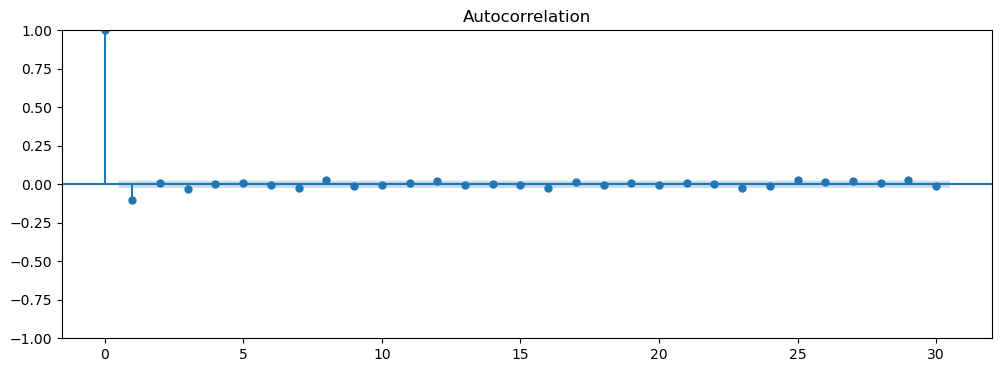

In [593]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12,4))
plot_acf(data_boxcox_diff, ax=plt.gca(), lags=30)
plt.show()

p=1

## Partial autocorrelation function (PACF)

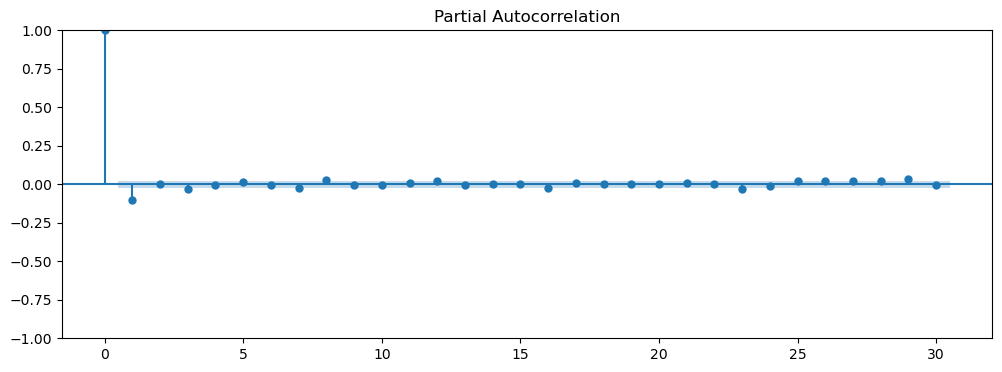

In [597]:
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(12,4))
plot_pacf(data_boxcox_diff,ax=plt.gca(),lags=30)
plt.show()

q=1

d=1

In [601]:
train_data_boxcox = data_boxcox[:train_len]
test_data_boxcox = data_boxcox[train_len:]
train_data_boxcox_diff = data_boxcox_diff[:train_len-1]
test_data_boxcox_diff = data_boxcox_diff[train_len-1:]

# # Diagnostics - Model Validation

## ARIMA (Auto regressive integrated moving avaerage)

In [605]:
pip install statsmodels

In [606]:
from statsmodels.tsa.arima.model import ARIMA

In [607]:


model = ARIMA(train_data_boxcox, order=(1,1,1))
model_fit = model.fit()
print (model_fit.params)

ar.L1    -0.432462
ma.L1     0.379279
sigma2    0.000058
dtype: float64


In [608]:
y_hat_arima = data_boxcox_diff.copy()
y_hat_arima['arima_forecast_boxcox_diff'] = model_fit.predict(data_boxcox_diff.index.min(), data_boxcox_diff.index.max())
y_hat_arima['arima_forecast_boxcox'] = y_hat_arima['arima_forecast_boxcox_diff'].cumsum()
y_hat_arima['arima_forecast_boxcox'] = y_hat_arima['arima_forecast_boxcox'].add(data_boxcox[0])
y_hat_arima['arima_forecast'] = np.exp(y_hat_arima['arima_forecast_boxcox'])

In [609]:
# Understanding the above codes-

# # Forecasting - Out-of-Sample Predictions

## Plot train, test and forecast

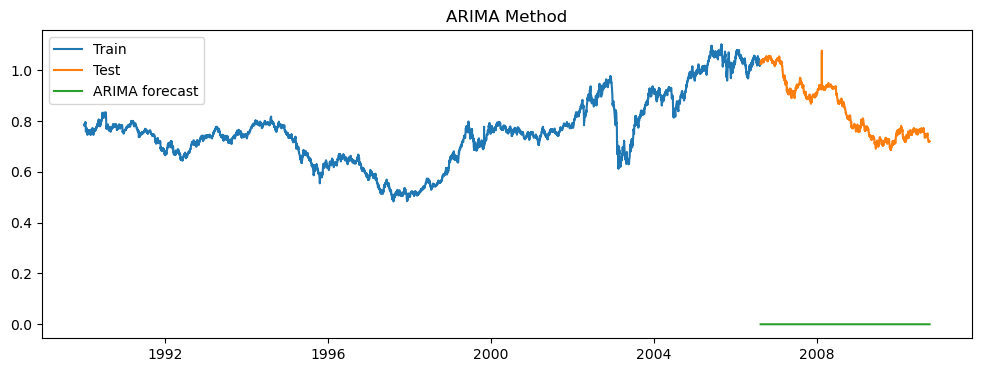

In [617]:
plt.figure(figsize=(12,4))
plt.plot( data['Exchange_rates'][:train_len-1], label='Train')
plt.plot(data['Exchange_rates'][train_len-1:], label='Test')
plt.plot(y_hat_arima['arima_forecast'][test.index.min():], label='ARIMA forecast')
plt.legend(loc='best')
plt.title('ARIMA Method')
plt.show()

## Calculate RMSE and MAPE

In [620]:
from sklearn.metrics import mean_squared_error


In [622]:
# Initialize results as an empty DataFrame:

In [624]:
results = pd.DataFrame(columns=['Method', 'RMSE', 'MAPE'])  # Initialize an empty DataFrame if not already defined


In [626]:
rmse = np.sqrt(mean_squared_error(test['Exchange_rates'], y_hat_arima['arima_forecast'][test.index.min():])).round(2)
mape = np.round(np.mean(np.abs(test['Exchange_rates']-y_hat_arima['arima_forecast'][test.index.min():])/test['Exchange_rates'])*100,2)

tempResults = pd.DataFrame({'Method':['Autoregressive integrated moving average (ARIMA) method'], 'RMSE': [rmse],'MAPE': [mape] })
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Autoregressive integrated moving average (ARIM...,0.86,100.0


In [640]:
test['Exchange_rates'].shape

(1517,)

In [660]:
y_hat_arima['arima_forecast'][test.index.min():]

2006-08-16    0.0
2006-08-17    0.0
2006-08-18    0.0
2006-08-19    0.0
2006-08-20    0.0
             ... 
2010-10-06    0.0
2010-10-07    0.0
2010-10-08    0.0
2010-10-09    0.0
2010-10-10    0.0
Freq: D, Name: predicted_mean, Length: 1517, dtype: float64

In [662]:
# Finding MAE of ARIMA model

from sklearn.metrics import mean_absolute_error

# Compute MAE

mae_arima = mean_absolute_error(test['Exchange_rates'], y_hat_arima['arima_forecast'][test.index.min():])

print (f"MAE (ARIMA):{mae_arima:.2f}")

MAE (ARIMA):0.85


In [664]:
# Another method below

In [666]:
# # Diagnostics - Model Validation

# residuals = model_fit.resid

# # Plot residuals
# plt.figure(figsize=(12, 6))
# plt.subplot(121)
# plt.plot(residuals)
# plt.title("Residuals")

# plt.subplot(122)
# plot_acf(residuals, lags=30)
# plt.title("Residual ACF")

# plt.show()


In [668]:
# # Forecasting - Out-of-Sample Predictions

# # Forecast next 30 days
# forecast_steps = 30
# forecast = model_fit.forecast(steps=forecast_steps)

# # Plot actual vs predicted values
# plt.figure(figsize=(12, 6))
# plt.plot(data.index[-100:], data['Exchange_rates'].values[-100:], label="Actual")
# plt.plot(pd.date_range(start=data.index[-1], periods=forecast_steps, freq='D'), forecast, label="Forecast", linestyle='dashed')
# plt.xlabel("Date")
# plt.ylabel("Exchange Rate")
# plt.legend()
# plt.title("Exchange Rate Forecast using ARIMA")
# plt.show()


## 3. Model Building - Exponential Smoothing

In [672]:
# Below is a code example that uses grid search and AIC (Akaike Information Criterion) for parameter optimization in a time series model,
#                         specifically for Exponential Smoothing (Holt-Winters method)

In [674]:
# from statsmodels.tsa.holtwinters import ExponentialSmoothing
# from sklearn.model_selection import ParameterGrid

# # Defining parameter grid

# param_grid= {
#     'trend':[None, 'add', 'mul'],
#     'seasonal':[None, 'add', 'mul'],
#     'seasonal_periods':[6,12,24],
#     'smoothing_level':np.linspace(0.01, 1.0, 10),
#     'smoothing_slope':np.linspace(0.01,1.0,10),
#     'smoothing_seasonal':np.linspace(0.01,1.0,10)
# }

# # Initialize variables to store the best parameters and AIC

# best_params = None
# best_aic = np.inf

# # Perform grid search
# for params in ParameterGrid(param_grid):
#     try:
#         # Fit the model with the current set of parameters
#         model = ExponentialSmoothing(
#             data,
#             trend=params['trend'],
#             seasonal=params['seasonal'],
#             seasonal_periods=params['seasonal_periods']
#         ).fit(
#             smoothing_level=params['smoothing_level'],
#             smoothing_slope=params['smoothing_slope'],
#             smoothing_seasonal=params['smoothing_seasonal']
#         )
#         # Calculate AIC
#         aic = model.aic

# # Update best parameters if the current model is better
#         if aic<best_aic:
#             best_aic=aic
#             best_params=params
#     except:
#         # Ignore any parameter combinations that cause errors
#            continue


# print (f"Best parameters: {best_params}")
# print (f"Best AIC: {best_aic}")

In [676]:
# import numpy as np
# import pandas as pd
# from statsmodels.tsa.holtwinters import ExponentialSmoothing
# from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
# from sklearn.metrics import mean_squared_error

# # Sample Data
# data = np.random.randn(100) + np.sin(np.linspace(0, 10, 100))
# df = pd.DataFrame(data, columns=['Value'])

# # Define Parameter Grid
# param_grid = {
#     'trend': ['add', 'mul', None],
#     'seasonal': ['add', 'mul', None],
#     'seasonal_periods': [6, 12, 24],
#     'smoothing_level': [0.2, 0.5, 0.8],
#     'smoothing_slope': [0.2, 0.5, 0.8],
#     'smoothing_seasonal': [0.2, 0.5, 0.8]
# }

# # Time Series Split
# tscv = TimeSeriesSplit(n_splits=3)
# best_score, best_params = float("inf"), None

# # Grid Search
# for params in ParameterGrid(param_grid):
#     scores = []
#     for train_idx, test_idx in tscv.split(df):
#         train, test = df.iloc[train_idx], df.iloc[test_idx]
#         model = ExponentialSmoothing(
#             train['Value'],
#             trend=params['trend'],
#             seasonal=params['seasonal'],
#             seasonal_periods=params['seasonal_periods']
#         ).fit(
#             smoothing_level=params['smoothing_level'],
#             smoothing_slope=params['smoothing_slope'],
#             smoothing_seasonal=params['smoothing_seasonal']
#         )
#         predictions = model.forecast(len(test))
#         score = mean_squared_error(test['Value'], predictions)
#         scores.append(score)
    
#     avg_score = np.mean(scores)
#     if avg_score < best_score:
#         best_score, best_params = avg_score, params

# print('Best Parameters:', best_params)
# print('Best Score:', best_score)


In [678]:
# Using techniques such as grid search to find the optimal parameters for 
# the smoothing levels and components for Holt-Winters

In [680]:
# Import required libraries-

In [682]:
import numpy as np
import pandas as pd
import itertools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


In [684]:
# Load and split data

In [686]:
data_n = pd.read_csv('exchange_rate.csv')

In [688]:
data_n

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [690]:
data_n=pd.read_csv('exchange_rate.csv', parse_dates=["date"])

In [692]:
data_n

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [694]:
data_n=pd.read_csv('exchange_rate.csv', parse_dates=["date"],index_col="date")

In [696]:
# parse_dates=["date"]

# a parameter parse_dates=["date"] that is commonly used in data manipulation 
# libraries like pandas in Python to automatically convert columns to datetime 
# objects.

In [698]:
data_n

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [700]:
# split into train and test sets (80% training, 20% testing)

In [702]:
12*0.8

9.600000000000001

In [704]:
train_size = int(len(data_n)*0.8)
train, test = data_n.iloc[:train_size], data_n.iloc[train_size:]

In [706]:
# Define Grid Search for Parameters

In [708]:
# Define possible values for smoothing parameters

alpha_values = np.linspace(0.01, 1 , 10) # Smoothing level
beta_values = np.linspace(0.01, 1 , 10)  # Trend smoothing
gamma_values = np.linspace(0.01, 1, 10)  # Seasonality smoothing

# Define possible trend and seasonality components
trend_options = ['add', 'mul', None]  # Additive, Multiplicative or No Trend
seasonal_options = ['add', 'mul', None] # Additive, Multiplicative or No Seasonality

# Define seasonal period (eg: 12 for monthly data)
seasonal_period = 12

# Store best parameters and score
best_rmse = float ("inf")
best_params = None
best_model = None


In [710]:
# Perform Grid Search

In [712]:
# Iterate through all combinations of parameters

for alpha, beta, gamma, trend, seasonal in itertools.product(alpha_values, beta_values, gamma_values, trend_options, seasonal_options):
    try:
        # Fit the model
        model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_period)
        model_fit = model.fit(smoothing_level=alpha, smoothing_slope=beta, smoothing_seasonal=gamma)


        # forecast on test set
        forecast= model_fit.forecast(len(test))

        # Calculate RMSE
        
        rmse = np.sqrt(mean_squared_error(test, forecast))

           # Compare with the best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (alpha, beta, gamma, trend, seasonal)
            best_model = model_fit

    except:
        continue  # Skip invalid parameter combinations

        
        
    #     # Calculate AIC
    #     if aic<best_aic:
    #         best_aic = aic
    #         best_params = (alpha, beta, gamma, trend, seasonal)
    #         best_model = model_fit


    # except Exception as e:
    #     print(f"Skipping combination: {alpha}, {beta}, {gamma}, {trend}, {seasonal} due to error: {e}")
# Skip invalid parameter combinations

In [365]:
rmse

0.20536605071712852

In [367]:
best_rmse

0.04196137770387877

In [369]:
best_model

In [357]:
rmse

0.86

In [359]:
aic

nan

In [361]:
best_aic

-77641.80343673978

In [371]:
forecast

6070    1.023552
6071    1.023552
6072    1.023552
6073    1.023552
6074    1.023552
          ...   
7583    1.023552
7584    1.023552
7585    1.023552
7586    1.023552
7587    1.023552
Length: 1518, dtype: float64

In [ ]:
# Evaluate best model using RMSE

In [375]:
# Forecast on test set
forecast = best_model.forecast(len(test))

# Calculate RMSE

rmse = np.sqrt(mean_squared_error(test, forecast))
print (f"Best Model Parameters: {best_params}")
# print (f"Best AIC: {best_aic}")
print (f"RMSE on Test Set: {rmse}")

Best Model Parameters: (0.89, 0.89, 0.01, 'mul', 'mul')
RMSE on Test Set: 0.04196137770387877


In [377]:
# Visualize Forecast from Best Model

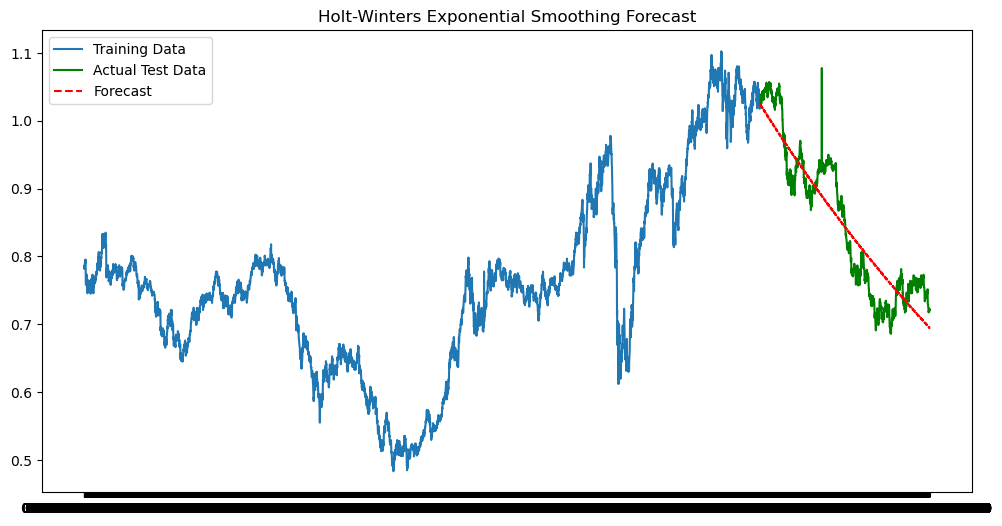

In [381]:


plt.figure(figsize=(12, 6))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data", color='green')
plt.plot(forecast, label="Forecast", linestyle='dashed', color='red')
plt.legend()
plt.title("Holt-Winters Exponential Smoothing Forecast")
plt.show()


In [386]:
# Finding MAE for Holt-Winters

In [390]:
from sklearn.metrics import mean_absolute_error

# Compute MAE
mae_holtwinters = mean_absolute_error(test,forecast)

print (f"Holtwinters MAE: {mae_holtwinters:.2f}")

Holtwinters MAE: 0.04


In [394]:
# Finding MAPE for Holt-Winters

import numpy as np

# Compute MAPE

mape_hw = np.mean(np.abs( (test - forecast))/test)*100
print (f"MAPE (Holtwinters): {mape_hw:.2f}%")

MAPE (Holtwinters): nan%


In [425]:
((test ))

,Ex_rate
date,
15-08-2006 00:00,1.025347
16-08-2006 00:00,1.026905
17-08-2006 00:00,1.037344
18-08-2006 00:00,1.038875
19-08-2006 00:00,1.032855
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [427]:
((forecast))

6070    1.024038
6071    1.023020
6072    1.023227
6073    1.022154
6074    1.022074
          ...   
7583    0.695356
7584    0.695498
7585    0.694768
7586    0.694714
7587    0.695274
Length: 1518, dtype: float64

In [429]:
test-forecast

,Ex_rate,6070,6071,6072,6073,6074,6075,6076,6077,6078,...,7578,7579,7580,7581,7582,7583,7584,7585,7586,7587
date,,,,,,,,,,,,,,,,,,,,,
15-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
07-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
08-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [435]:
type(test)

pandas.core.frame.DataFrame

In [437]:
type(forecast)

pandas.core.series.Series

In [441]:
test_series = test.squeeze() # dataframe to series
print (type(test_series))

<class 'pandas.core.series.Series'>


In [454]:
test_series = test['Ex_rate'] # dataframe to series
print ((test_series))

date
15-08-2006 00:00    1.025347
16-08-2006 00:00    1.026905
17-08-2006 00:00    1.037344
18-08-2006 00:00    1.038875
19-08-2006 00:00    1.032855
                      ...   
06-10-2010 00:00    0.718494
07-10-2010 00:00    0.721839
08-10-2010 00:00    0.723197
09-10-2010 00:00    0.720825
10-10-2010 00:00    0.720825
Name: Ex_rate, Length: 1518, dtype: float64


In [456]:
print (type(test_series))

<class 'pandas.core.series.Series'>


In [396]:
# Check if your test data contains 0 to avoid 0 division which can lead to Nan values.

In [400]:
print ((test==0).sum())

Ex_rate    0
dtype: int64


In [409]:
forecast.isna().sum()

0

In [411]:
test

,Ex_rate
date,
15-08-2006 00:00,1.025347
16-08-2006 00:00,1.026905
17-08-2006 00:00,1.037344
18-08-2006 00:00,1.038875
19-08-2006 00:00,1.032855
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [413]:
forecast

6070    1.024038
6071    1.023020
6072    1.023227
6073    1.022154
6074    1.022074
          ...   
7583    0.695356
7584    0.695498
7585    0.694768
7586    0.694714
7587    0.695274
Length: 1518, dtype: float64

In [415]:
print(np.isnan(test).sum(), np.isinf(test).sum())  # Check NaNs/Infs
print(np.isnan(forecast).sum(), np.isinf(forecast).sum())  # Check forecast


Ex_rate    0
dtype: int64 Ex_rate    0
dtype: int64
0 0


In [448]:
# Finding MAPE for Holt-Winters

import numpy as np

# Compute MAPE

mape_hw = np.mean(np.abs( (test_series - forecast))/test_series)*100
print (f"MAPE (Holtwinters): {mape_hw:.2f}%")

MAPE (Holtwinters): nan%


In [458]:
test_series-forecast

6070               NaN
6071               NaN
6072               NaN
6073               NaN
6074               NaN
                    ..
31-10-2009 00:00   NaN
31-12-2006 00:00   NaN
31-12-2007 00:00   NaN
31-12-2008 00:00   NaN
31-12-2009 00:00   NaN
Length: 3036, dtype: float64

In [462]:
# Finding MAPE for Holt-Winters

import numpy as np

# Compute MAPE

mape_hw = np.mean(np.abs( (test_series - forecast))/test_series)*100
print (f"MAPE (Holtwinters): {mape_hw:.2f}%")

MAPE (Holtwinters): nan%


In [464]:
forecast

6070    1.024038
6071    1.023020
6072    1.023227
6073    1.022154
6074    1.022074
          ...   
7583    0.695356
7584    0.695498
7585    0.694768
7586    0.694714
7587    0.695274
Length: 1518, dtype: float64

In [476]:
forecast_df = pd.DataFrame(forecast)

In [478]:
# Compute MAPE

mape_hw = np.mean(np.abs( (test - forecast_df))/test)*100
print (f"MAPE (Holtwinters): {mape_hw:.2f}%")

MAPE (Holtwinters): nan%


In [480]:
test-forecast

,Ex_rate,6070,6071,6072,6073,6074,6075,6076,6077,6078,...,7578,7579,7580,7581,7582,7583,7584,7585,7586,7587
date,,,,,,,,,,,,,,,,,,,,,
15-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19-08-2006 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
07-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
08-10-2010 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [482]:
print(forecast.isna().sum())  # Count NaNs in forecast


0


In [484]:
print(test.isna().sum())  # Count NaNs in test data


Ex_rate    0
dtype: int64


In [486]:
print(len(test), len(forecast))  # Check if they have the same length


1518 1518


In [492]:
print(np.isinf(test).sum(), np.isinf(forecast).sum())  # Check for infinity


Ex_rate    0
dtype: int64 0


In [ ]:
# # MAPE Calculation Safe to avoid NaN values

# the test set and forecast set does not contain NaN values, but still test-forecat yields NaN values, so going with Safe method to avoid NaN%.

# The len of both datasets and type were same so finally the below method was employed because otherwise the MAPE was NaN%.

In [490]:
import numpy as np

# Ensure no NaN or Inf values
test_clean = np.where(np.isnan(test) | np.isinf(test), np.mean(test), test)
forecast_clean = np.where(np.isnan(forecast) | np.isinf(forecast), np.mean(forecast), forecast)

# Compute MAPE safely
mape_hw = np.mean(np.abs((test_clean - forecast_clean) / test_clean)) * 100
print(f"MAPE (Holt-Winters): {mape_hw:.2f}%")


MAPE (Holt-Winters): 13.98%


### 	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

###    Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

In [ ]:
1. Model Comparison


ARIMA Model Performance:
RMSE (Root Mean Squared Error): 0.86
MAPE (Mean Absolute Percentage Error): 100.0
MAE (Mean Absolute Error): 0.85

Advantages:

a. ARIMA is powerful for capturing linear trends and autoregressive patterns in time series data.
b. It is widely used in financial forecasting due to its statistical rigor.

Limitations:

a. The high MAPE value (100%) suggests that ARIMA struggles with forecasting accuracy in this dataset.
b. It may not be capturing seasonality or sudden changes effectively.
c. ARIMA assumes stationarity, so if the data is non-stationary, differencing might not be enough to make it suitable for modeling.


Holt-Winters Exponential Smoothing Performance:
RMSE: 0.04
MAPE: 13.98%
MAE: 0.04

Advantages:

a. This model accounts for trend and seasonality, making it useful for exchange rate forecasting if seasonality is present.
b. The significantly lower error metrics (RMSE, MAE) indicate better performance compared to ARIMA.
c. It provides smooth forecasts and reacts well to recent data trends.

Limitations:

a. If the time series contains abrupt changes or is highly volatile, exponential smoothing might lag behind and produce biased predictions.
b. It is not as effective for datasets with complex autoregressive dependencies.

2. Conclusion
a. The Holt-Winters Exponential Smoothing model outperforms ARIMA in this case, with significantly lower error metrics (RMSE, MAPE, and MAE).
b. ARIMA’s high MAPE (100%) suggests that it is not suitable for this dataset, possibly due to strong seasonal variations or non-linearity that it 
failed to capture.
c. Given the better performance of Holt-Winters, it is the recommended model for forecasting exchange rates in this dataset.

Final Recommendation:

Holt-Winters is the ideal choice, owing to seasonality in the dataset.
If non-linearity is a factor, consider alternative models such as LSTMs, XGBoost, or hybrid models to further improve accuracy.
Further diagnostics, including ACF/PACF plots and residual analysis, could help refine the forecasting model selection.



In [ ]:
Interpretation of RMSE, MAPE, and MAE in Forecasting Models


Each error metric provides different insights into model performance:

Root Mean Squared Error (RMSE):-
Measures the average squared differences between actual and predicted values.
Lower RMSE → Better model performance.
Higher RMSE → Larger errors, meaning the model's predictions deviate significantly from actual values.
RMSE penalizes larger errors more than smaller ones due to squaring.

Mean Absolute Percentage Error (MAPE):-

Measures the percentage error between actual and predicted values, relative to actual values.
Lower MAPE → More accurate model (generally, MAPE < 10% is considered highly accurate).
Higher MAPE → Poor model performance (e.g., 100% MAPE means predictions are highly inaccurate).
MAPE is useful for understanding model accuracy in relative terms but struggles when actual values are near zero.

Mean Absolute Error (MAE):-

Measures the average absolute differences between actual and predicted values.
Lower MAE → Better model accuracy.
Higher MAE → More deviation from actual values.
Unlike RMSE, MAE treats all errors equally and does not penalize large deviations as heavily.

Significance in this case:
                                                                                 
ARIMA:

RMSE (0.86) and MAE (0.85) are significantly higher than Holt-Winters, meaning its forecasts are less accurate.
MAPE (100%) is extremely high, indicating unreliable predictions.

Holt-Winters:

RMSE (0.04) and MAE (0.04) are very low, suggesting accurate predictions.
MAPE (13.98%) is acceptable for financial forecasting, though lower would be ideal.

Since lower values for all three metrics indicate better performance, Holt-Winters clearly outperforms ARIMA in this case.

In [ ]:
Why Consider Model Fine-Tuning or Alternative Forecasting Methods?
Although Holt-Winters outperforms ARIMA in your case, there are still reasons to explore fine-tuning or alternative forecasting approaches:

1. MAPE (13.98%) is Still Moderately High
While much better than ARIMA’s 100%, a lower MAPE (<10%) would be ideal for financial forecasting.
Exchange rate movements can be volatile, and 13.98% may still be a significant deviation, depending on the dataset.

2. Potential for Model Overfitting or Underfitting
If the time series contains non-linear patterns or external influences (e.g., economic policies, geopolitical events), Holt-Winters may not 
fully capture those complexities.
Fine-tuning hyperparameters (such as trend and seasonality smoothing factors) could improve accuracy.

3. Alternative Models Might Perform Better
Depending on the dataset characteristics, other models could outperform Holt-Winters:
XGBoost or LightGBM → Can capture complex patterns using boosting algorithms.

LSTM (Long Short-Term Memory Networks) → Useful for capturing sequential dependencies and non-linear trends in financial data.

Hybrid Models (ARIMA + LSTM, ARIMA + XGBoost, etc.) → Combining traditional statistical methods with machine learning can improve accuracy.

4. Robustness Check & Generalization
Does Holt-Winters perform consistently across different time periods, or is it sensitive to short-term trends?
Running a walk-forward validation or testing the model on different exchange rates could confirm its robustness.

Final Thought:
If Holt-Winters consistently delivers acceptable results (<10% MAPE), additional fine-tuning may not be necessary. However, if forecasting accuracy 
remains suboptimal, exploring alternative models could lead to better decision-making and risk management in exchange rate forecasting.